In [1]:
import os
import sys
# if 'home' not in os.getcwd():
#     base_path = 'D:'
# else:
#     base_path = os.getcwd()    
# folder_path =f"{base_path}/DataScience"
# sys.path.append(f"{folder_path}/DS_Library")

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

In [3]:
import torch

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"torch_device : {device}")


torch_device : cuda:0


In [4]:

try:
    from DS_DeepLearning import EarlyStopping, TorchModeling
    
except:
    remote_library_url = 'https://raw.githubusercontent.com/kimds929/'
    try:
        import httpimport
        with httpimport.remote_repo(f"{remote_library_url}/DS_Library/main/"):
            from DS_DeepLearning import EarlyStopping, TorchModeling
    except:
        import requests
        response = requests.get(f"{remote_library_url}/DS_Library/main/DS_DeepLearning.py", verify=False)
        exec(response.text)

In [5]:
###################################################################################################
rng = np.random.RandomState(1)

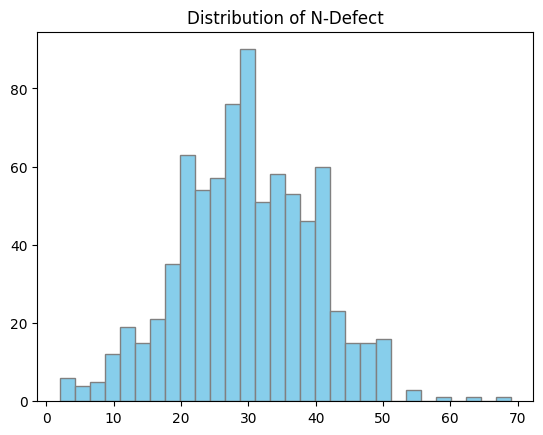

In [6]:

# --------------------------------------------------------------------------------------------------
scale = 1/50
# n_log_mean = 1.8
# n_log_std = 1
# n_sample = 20
# n_defect = (10 ** rng.normal(loc=n_log_mean, scale=n_log_std, size=n_sample) *scale ).astype(int)

n_mean = 30
n_std = 10
n_sample = 800       # n_samples ★
n_defect = rng.normal(loc=n_mean, scale=n_std, size=n_sample).astype(int)

# visualize
plt.title('Distribution of N-Defect')
plt.hist(n_defect, bins=30, color='skyblue', edgecolor='gray')
plt.show()


In [7]:
# --------------------------------------------------------------------------------------------------

w_mean = 1250
w_std = 150
l_log_mean = 3
l_log_std = 0.2

size_w = rng.normal(loc=w_mean, scale=w_std, size=(n_sample,1)).round(1) *scale
size_l = (10**rng.normal(loc=l_log_mean, scale=l_log_std, size=(n_sample,1))).round(1) *scale
sizes = np.concatenate([size_w, size_l], axis=1)

# --------------------------------------------------------------------------------------------------

df = pd.DataFrame()
mtl_list = []
for i in range(n_sample):
    n_defect_i = n_defect[i]
    if n_defect_i > 0:
        defect_locs = (np.random.rand(n_defect_i,2) * sizes[i]).round(1)
        size_broadcast = np.ones_like(defect_locs) * sizes[i]
        mtl_mat = np.concatenate([size_broadcast, defect_locs], axis=1)
        mtl_list.append(mtl_mat)
        df_sub = pd.DataFrame(mtl_mat, columns=['W', 'L', 'loc_w', 'loc_l'])
        df_sub.insert(0, 'mtl_idx', f"mtl_{i:05d}")
        df = pd.concat([df, df_sub], axis=0)


df.groupby(['mtl_idx']).size().sample(10)


mtl_idx
mtl_00351    39
mtl_00255    19
mtl_00788    24
mtl_00734    26
mtl_00397    39
mtl_00356    31
mtl_00522    31
mtl_00271    45
mtl_00573    48
mtl_00367     2
dtype: int64

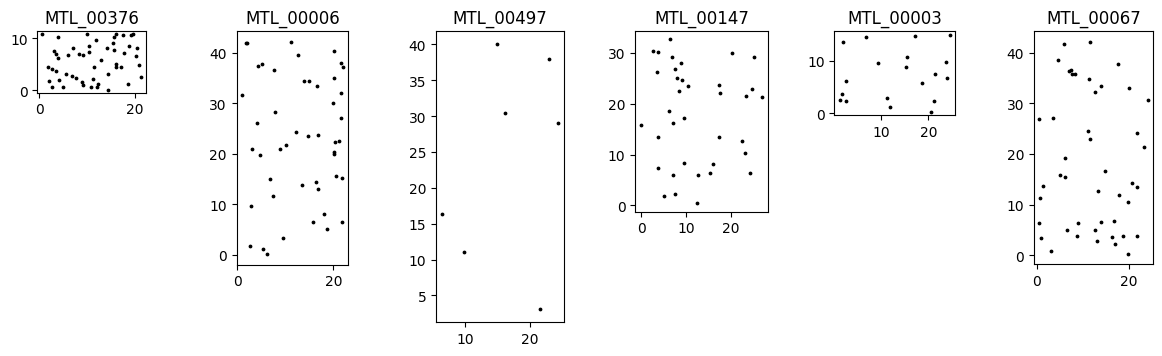

In [8]:

# --------------------------------------------------------------------------------
# visualize
# plt.figure(figsize=[mtl_sample[0][0]/6 , mtl_sample[0][1]/3])
# idx = 2


plt.figure(figsize=(15,8))
for i, idx in enumerate([376, 6, 497, 147, 3, 67]):
    ax = plt.subplot(1,6, i+1)
    ax.set_title(f"MTL_{idx:05d}")
    mtl_sample = mtl_list[idx]
    plt.scatter(mtl_sample[:,-2], mtl_sample[:,-1], c="black", s=3)
    
    pos = ax.get_position()     # 현재 위치 가져오기
    
    w_width = mtl_sample[0][0] / sizes.max(axis=0)[0]
    w_height = mtl_sample[0][1] / sizes.max(axis=0)[1]
    new_height = pos.height * w_height
    new_y0 = pos.y0 + (pos.height - new_height)  # 위쪽 고정
    
    ax.set_position([pos.x0, new_y0, pos.width*w_width, pos.height*w_height]) # 크기 조정 (width, height 변경)

plt.show()


In [9]:
# --------------------------------------------------------------------------------
# from DS_TimeSeries import pad_series_list
from torch.nn.utils.rnn import pad_sequence
mtl_list_torch = [torch.FloatTensor(mtl) for mtl in mtl_list]

pad_series_torch = pad_sequence(mtl_list_torch, padding_value=-1, batch_first=True)     # (N, Seq, features)
print(pad_series_torch.shape)
print(pad_series_torch)

torch.Size([800, 69, 4])
tensor([[[27.4440, 22.8680, 15.2000, 14.7000],
         [27.4440, 22.8680, 26.9000, 16.2000],
         [27.4440, 22.8680, 12.1000, 18.1000],
         ...,
         [-1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000]],

        [[27.3420, 32.8100,  5.3000,  7.5000],
         [27.3420, 32.8100,  5.8000, 31.5000],
         [27.3420, 32.8100, 16.8000, 21.7000],
         ...,
         [-1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000]],

        [[20.6080, 14.5040, 10.5000,  8.0000],
         [20.6080, 14.5040, 13.7000,  5.4000],
         [20.6080, 14.5040, 14.8000,  8.9000],
         ...,
         [-1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000]],

        ...,

        [[22.5900,  9.4140, 16.6000,  2.7000],
         [22.5900,  

In [10]:
################################################################################
import torch.nn as nn
import torch.optim as optim

In [11]:

class Kernel(nn.Module):
    def __init__(self, Sigma=None, boundary=None, kernel='gaussian', valid_masking=True):
        super().__init__()
        self.Sigma = nn.Parameter(torch.rand(1)) if Sigma is None else Sigma
        self.boundary = nn.Parameter(torch.rand(1)) if boundary is None else boundary
        self.valid_masking = valid_masking
        self.epsilon = 1e-6
        
        self.kernel = kernel
    
    def _is_mat(self, p):
        return p is not None and getattr(p, "ndim", 0) == 2
    
    def square_mahalanobis_dist(self, X, Y=None, Sigma=None):
        """pairwise distance: Euclidean (optional /sigma) or Mahalanobis (Sigma matrix)."""
        Y = X if Y is None else Y
        D = X.unsqueeze(-2) - Y.unsqueeze(-3)                # (B,n,m,d)

        if self._is_mat(Sigma):
            Sigma_inv = torch.linalg.inv(Sigma)
            s = (D @ Sigma_inv * D).sum(dim=-1) 
            # s =  torch.einsum("nmd,dd,nmd->nm", D, torch.linalg.inv(Sigma), D)
        else:
            Sigma = 1 if Sigma is None else Sigma
            s = (D*D).sum(dim=-1) / (Sigma)
            # s = torch.einsum("nmd,nmd->nm", D, D) / (Sigma**2)       # (D*D).sum(-1)/(Sigma**2)
        s =  s.clamp_min(0)
        return s

    def _u(self, X, Y=None, boundary=1.0):
        """normalized distance for compact kernels."""
        if self._is_mat(boundary):          # ellipsoid: already normalized, boundary at u<=1
            return torch.sqrt( self.square_mahalanobis_dist(X, Y, Sigma=boundary**2) + self.epsilon )     # gradient explosion 방지
        return torch.sqrt( self.square_mahalanobis_dist(X, Y) + self.epsilon ) / boundary     # gradient explosion 방지

    def _valid_seq_len(self, X):
        """
        X: (..., Seq, Feature)
        각 배치별로 유효한 시퀀스 길이를 반환 (list of lengths)
        """
        # 마지막 Feature 차원 기준으로 유효 여부 판단
        valid_mask = ((X >= 0) & (X < torch.inf)).all(dim=-1)  # (..., Seq)
        # 각 배치별 유효한 시퀀스 길이 계산
        valid_len = valid_mask.sum(dim=-1)  # (...,)
        return valid_len
    
    def gaussian_kernel(self, X, Y=None, Sigma=1.0):
        d_square = self.square_mahalanobis_dist(X, Y, Sigma=Sigma)
        return torch.exp(-0.5 * d_square)

    def uniform_kernel(self, X, Y=None, boundary=1.0):
        u = self._u(X, Y, boundary)
        return (u <= 1).to(dtype=u.dtype)

    def linear_kernel(self, X, Y=None, boundary=1.0):
        u = self._u(X, Y, boundary)
        return torch.clamp(1 - u, 0, 1)

    def epanechnikov_kernel(self, X, Y=None, boundary=1.0):
        u = self._u(X, Y, boundary)
        return torch.clamp(1 - u*u, 0, 1)

    def quartic_kernel(self, X, Y=None, boundary=1.0):
        u = self._u(X, Y, boundary)
        t = torch.clamp(1 - u*u, 0, 1)
        return t*t

    def forward_kernel(self, X, Y=None, kernel=None, Sigma=None, boundary=None, valid_masking=None):
        Y = X if Y is None else Y
        Sigma = self.Sigma if Sigma is None else Sigma
        boundary = self.boundary if boundary is None else boundary
        valid_masking = self.valid_masking if valid_masking is None else valid_masking
        kernel = self.kernel if kernel is None else kernel
        
        kernel_result = None
        if kernel == 'gaussian':
            kernel_result = self.gaussian_kernel(X, Y, Sigma)
        elif kernel == 'uniform':
            kernel_result = self.uniform_kernel(X, Y, boundary)
        elif kernel == 'linear':
            kernel_result = self.linear_kernel(X, Y, boundary)
        elif kernel == 'epanechnikov':
            kernel_result = self.epanechnikov_kernel(X, Y, boundary)
        elif kernel == 'quartic':
            kernel_result = self.quartic_kernel(X, Y, boundary)
        
        if valid_masking is True:
            valid_len_X = self._valid_seq_len(X)    # shape: batch_dims...
            valid_len_Y = self._valid_seq_len(Y)    # shape: batch_dims...
            
            seq_x = kernel_result.shape[-2]
            seq_y = kernel_result.shape[-1]

            # 시퀀스 인덱스 생성
            idx_x = torch.arange(seq_x, device=kernel_result.device)  # (Seq_X,)
            idx_y = torch.arange(seq_y, device=kernel_result.device)  # (Seq_Y,)

            # 브로드캐스팅을 위해 차원 확장
            # valid_len_X: (..., 1, 1) → 비교 시 (..., Seq_X, 1)
            # valid_len_Y: (..., 1, 1) → 비교 시 (..., 1, Seq_Y)
            mask_x = idx_x.unsqueeze(0) < valid_len_X.unsqueeze(-1)  # (..., Seq_X)
            mask_y = idx_y.unsqueeze(0) < valid_len_Y.unsqueeze(-1)  # (..., Seq_Y)

            # 브로드캐스팅으로 최종 mask 생성
            # mask_x[..., :, None] : (..., Seq_X, 1)
            # mask_y[..., None, :] : (..., 1, Seq_Y)
            mask = mask_x[..., :, None] & mask_y[..., None, :]

            kernel_result = kernel_result.masked_fill(~mask, 0)
        return kernel_result

    def forward(self, X, Y=None, kernel=None, Sigma=None, boundary=None, valid_masking=None):
        dist_mat = self.forward_kernel(X, Y=Y, kernel=kernel, Sigma=Sigma, boundary=boundary, valid_masking=valid_masking)
        dist = torch.sum(dist_mat, dim=-1, keepdim=True)
        return dist

################################################################################

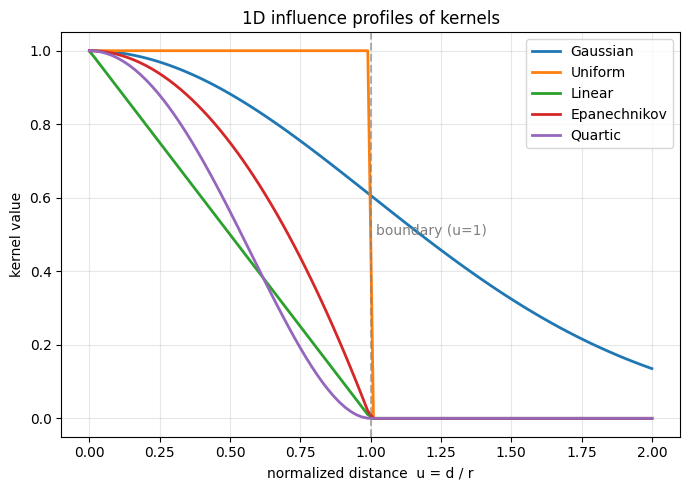

In [12]:
# (visualize kernels) normalized distance u = d / r
base_point = torch.zeros([1,1])
u = torch.linspace(0, 2.0, 100).reshape(-1,1)


kernel = Kernel(Sigma=1, boundary=1)
with torch.no_grad():
    K_gaussian = kernel.forward_kernel(u, base_point, kernel='gaussian')[0].sum(-1)           # exp(-1/2 u^2) : np.exp(-0.5 * u**2)
    K_uniform = kernel.forward_kernel(u, base_point, kernel='uniform')[0].sum(-1)             # 1 (u≤1), 0 (u>1) : (u <= 1.0).astype(float)
    K_linear = kernel.forward_kernel(u, base_point, kernel='linear')[0].sum(-1)               # max(0, 1-u) : np.clip(1.0 - u, 0.0, 1.0)
    K_epanechnikov = kernel.forward_kernel(u, base_point, kernel='epanechnikov')[0].sum(-1)   # max(0, 1-u^2) : np.clip(1.0 - u**2, 0.0, 1.0)
    K_quartic = kernel.forward_kernel(u, base_point, kernel='quartic')[0].sum(-1)             # max(0, (1-u^2)^2) : np.clip(1.0 - u**2, 0.0, 1.0)**2


# visualize plot
plt.figure(figsize=(7,5))
plt.plot(u, K_gaussian, label="Gaussian", linewidth=2)          # exp(-1/2 u^2) : np.exp(-0.5 * u**2)
plt.plot(u, K_uniform, label="Uniform", linewidth=2)            # 1 (u≤1), 0 (u>1) : (u <= 1.0).astype(float)
plt.plot(u, K_linear, label="Linear", linewidth=2)              # max(0, 1-u) : np.clip(1.0 - u, 0.0, 1.0)
plt.plot(u, K_epanechnikov, label="Epanechnikov", linewidth=2)  # max(0, 1-u^2) : np.clip(1.0 - u**2, 0.0, 1.0)
plt.plot(u, K_quartic, label="Quartic", linewidth=2)            # max(0, (1-u^2)^2) : np.clip(1.0 - u**2, 0.0, 1.0)**2

plt.axvline(1.0, color="gray", linestyle="--", alpha=0.6)
plt.text(1.02, 0.5, "boundary (u=1)", color="gray")

plt.xlabel("normalized distance  u = d / r")
plt.ylabel("kernel value")
plt.title("1D influence profiles of kernels")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

################################################################################

In [13]:
# Influence Visualize
def plot_influence(points, boundary=1, kernel='linear'):
    kernel_instance = Kernel(kernel=kernel, boundary=boundary, valid_masking=False)
    x_grid = torch.linspace(-3, 3, 300).reshape(-1, 1)  # 1D grid
    
    total_influence = torch.zeros_like(x_grid[:, 0])
    
    # 각 점의 영향력 계산 및 개별 곡선 그리기
    for p in points:
        with torch.no_grad():
            influence = kernel_instance.forward_kernel(x_grid, torch.FloatTensor([[p]]))[:,0]
        plt.scatter(p,0, s=80)
        total_influence += influence
        plt.plot(x_grid, influence, label=f'Point {p}', alpha=0.7)
        

    # 전체 합산 영향력
    plt.plot(x_grid, total_influence, 'k-', linewidth=2, label='Total Influence')

    # 각 점 위치에서 total influence 값 표시
    for p in points:
        idx = np.argmin(np.abs(x_grid[:, 0] - p))  # p에 가장 가까운 grid index
        total_val = total_influence[idx]
        plt.text(p, total_val + 0.05, f"{total_val:.2f}", 
                 ha='center', color='red', fontsize=9, fontweight='bold')
    
    plt.title(f"{kernel.capitalize()} influence, boundary={boundary}, points={points}")
    plt.xlabel("Position")
    plt.ylabel("Influence")
    plt.legend()
    plt.ylim(-0.05, 2.5)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3320\2032727681.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  idx = np.argmin(np.abs(x_grid[:, 0] - p))  # p에 가장 가까운 grid index


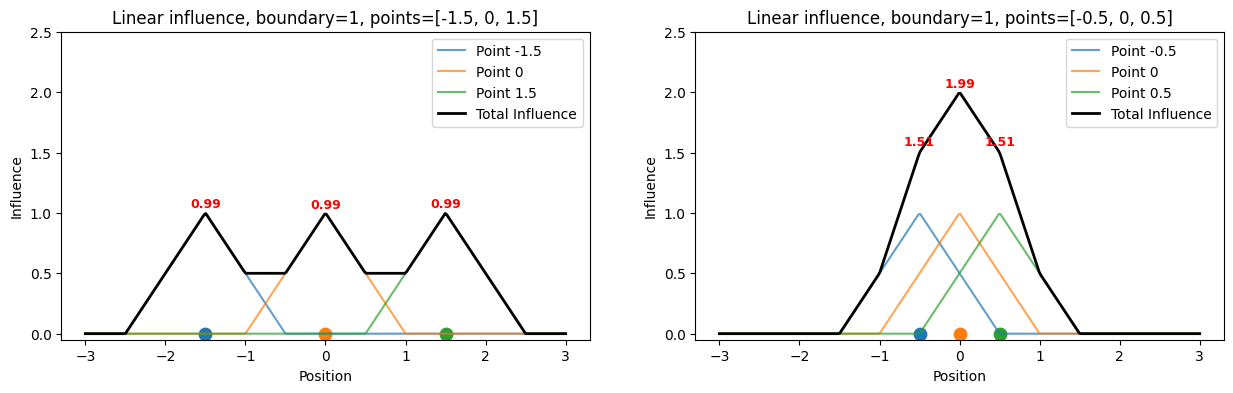

In [14]:

plt.figure(figsize=(15, 4))
plt.subplot(1,2,1)
plot_influence(points=[-1.5, 0, 1.5], boundary=1, kernel='linear')
plt.subplot(1,2,2)
plot_influence(points=[-0.5, 0, 0.5], boundary=1, kernel='linear')
plt.show()


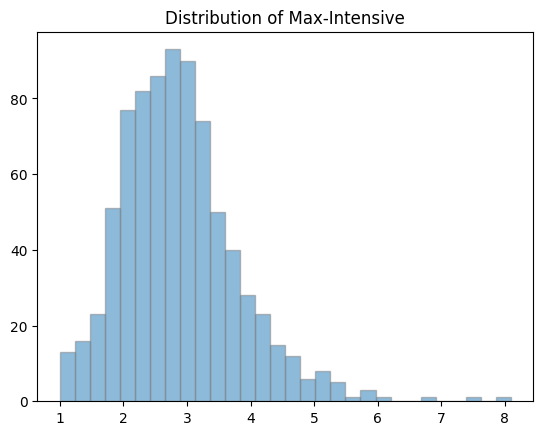

In [15]:
##########################################################################################

Sigma = 2.0
threshold = 4       # true threshold

# X = pad_series_torch[:,:,-2:]
# X.shape # (N, Seq, f)

# distance
dist = Kernel(Sigma=torch.tensor(Sigma), kernel='gaussian')
# dist = Kernel( boundary=torch.tensor(4), kernel='linear')


dist_mat = dist.forward_kernel(pad_series_torch[:,:,-2:])
# pd.DataFrame(dist_mat[3].numpy().round(1)).to_clipboard()
intensives = dist.forward(pad_series_torch[:,:,-2:]).squeeze(-1)
max_intensives = intensives.max(dim=-1)[0].numpy()


# intensive
# print(n_defect)
# print(max_intensives)
# np.stack([n_defect, max_intensives.numpy()]).T

plt.title('Distribution of Max-Intensive')
plt.hist(max_intensives, bins=30, edgecolor='gray', alpha=0.5)
plt.show()

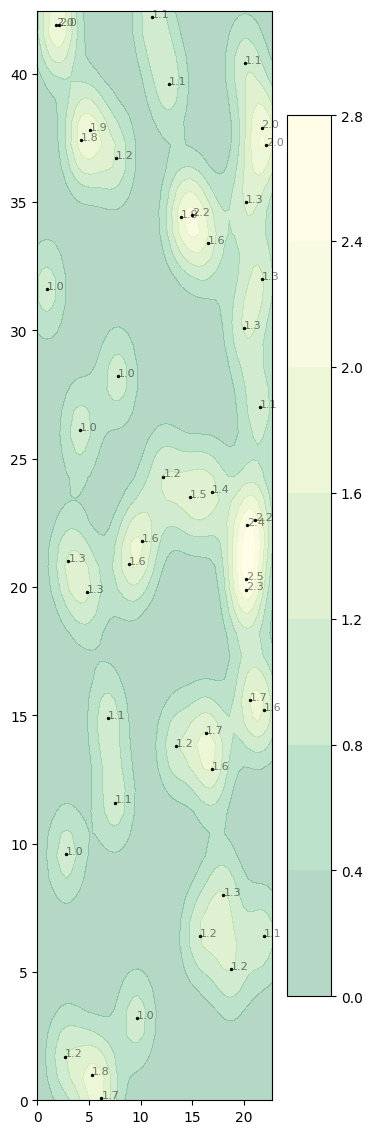

In [16]:
# Visualize
xx, yy = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))
grid = np.c_[xx.ravel(), yy.ravel()]  # (40000, 2)

i = 6
mtl_sample = mtl_list[i]
x_scale, y_scale = map(lambda x: x.item(), mtl_sample.mean(0)[:2])
gird_scale = grid * np.array([x_scale, y_scale])
xx_scale = xx * x_scale
yy_scale = yy * y_scale
Z = dist.forward(torch.FloatTensor(gird_scale), torch.FloatTensor(mtl_sample[:, -2:]) ).view(xx_scale.shape).detach().numpy()
intensive = intensives[i]

plt.figure(figsize=[mtl_sample[0][0].item()/6 , mtl_sample[0][1].item()/3])
# cont = plt.contourf(xx_scale, yy_scale, Z, cmap="RdYlGn_r", alpha=0.3, level=np.round(np.sqrt(np.linspace(1, 5**2, 11)), 1))
cont = plt.contourf(xx_scale, yy_scale, Z, cmap="RdYlGn_r", alpha=0.3, vmin=0, vmax=5)

for (xp, yp), val in zip(mtl_sample[:,-2:], intensive):
    color='black'
    alpha=0.5
    if val >= 4:
        color='red'
        alpha= 1
    plt.scatter(xp.item(), yp.item(), color=color, s=2)
    plt.text(xp.item(), yp.item(), round(val.item(),1), color=color, alpha=alpha, fontsize=8)

plt.colorbar(cont)
plt.show()


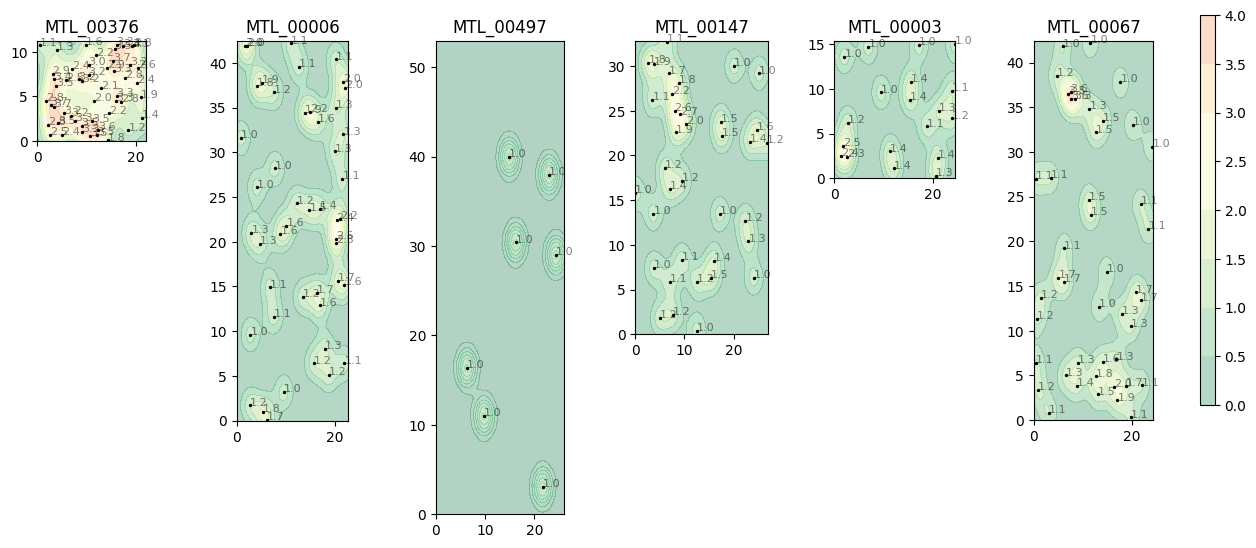

In [17]:
xx, yy = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))
grid = np.c_[xx.ravel(), yy.ravel()]  # (2500, 2)

plt.figure(figsize=(15, 13))
for i, idx in enumerate([376, 6, 497, 147, 3, 67]):
    ax = plt.subplot(1, 6, i+1)
    ax.set_title(f"MTL_{idx:05d}")
    
    mtl_sample = mtl_list[idx]
    x_scale, y_scale = map(lambda x: x.item(), mtl_sample.mean(0)[:2])
    gird_scale = grid * np.array([x_scale, y_scale])
    xx_scale = xx * x_scale
    yy_scale = yy * y_scale
    
    Z = dist.forward(
        torch.FloatTensor(gird_scale),
        torch.FloatTensor(mtl_sample[:, -2:])
    ).view(xx_scale.shape).detach().numpy()
    
    intensive = intensives[idx]
    
    # contour plot
    cont = ax.contourf(xx_scale, yy_scale, Z, cmap="RdYlGn_r", alpha=0.3, vmin=0, vmax=5)
    
    # scatter + text
    for (xp, yp), val in zip(mtl_sample[:, -2:], intensive):
        color = 'black'
        alpha = 0.5
        if val >= threshold:
            color = 'red'
            alpha = 1
        ax.scatter(xp.item(), yp.item(), color=color, s=2)
        ax.text(xp.item(), yp.item(), round(val.item(), 1), color=color, alpha=alpha, fontsize=8)
    
    # subplot 위치 조정
    pos = ax.get_position()
    w_width = mtl_sample[0][0].item() / sizes.max(axis=0)[0]
    w_height = mtl_sample[0][1].item() / sizes.max(axis=0)[1]
    new_height = pos.height * w_height
    new_y0 = pos.y0 + (pos.height - new_height)  # 위쪽 고정
    ax.set_position([pos.x0, new_y0, pos.width * w_width, pos.height * w_height])


# 공통 colorbar
cbar_ax = plt.gcf().add_axes([0.90, 0.6, 0.01, 0.3]) 
plt.colorbar(cont, cax=cbar_ax)

plt.show()


tensor([693, 107])


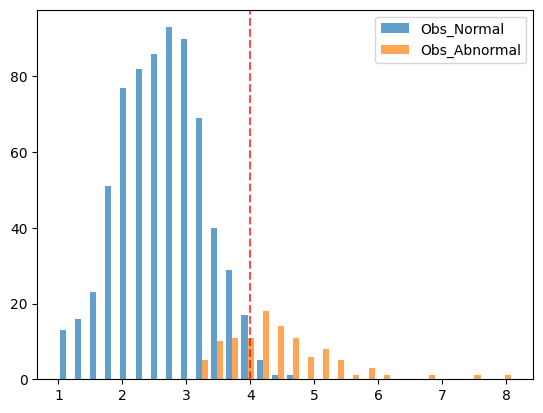

In [18]:

##########################################################################################
# --------------------------------------------------------------------------------

# calculate intensive
dist = Kernel(Sigma=torch.tensor(2.0), kernel='gaussian')
intensives = dist.forward(pad_series_torch[:,:,-2:]).squeeze(-1)
max_intensives = intensives.max(dim=-1)[0].numpy()

# Labeling
noise = rng.normal(loc=0, scale=0.5, size=max_intensives.shape)
label_true = ((max_intensives) > threshold).astype(int)
label_obs = ((max_intensives + noise) > threshold).astype(int)

label_torch = torch.LongTensor(label_obs)
num_classes = torch.unique(label_torch, return_counts=True)[1]
print(num_classes)

# visualize
plt.hist([max_intensives[label_obs==0], max_intensives[label_obs==1]],
        bins=30, alpha=0.7, label=['Obs_Normal','Obs_Abnormal'])
plt.legend()
plt.axvline(threshold, color='red', alpha=0.7, ls='--')
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(label_true, label_torch))   # true - obs
print(classification_report(label_torch, label_true))   # true - obs
##########################################################################################

[[681  35]
 [ 12  72]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       693
           1       0.86      0.67      0.75       107

    accuracy                           0.94       800
   macro avg       0.90      0.83      0.86       800
weighted avg       0.94      0.94      0.94       800



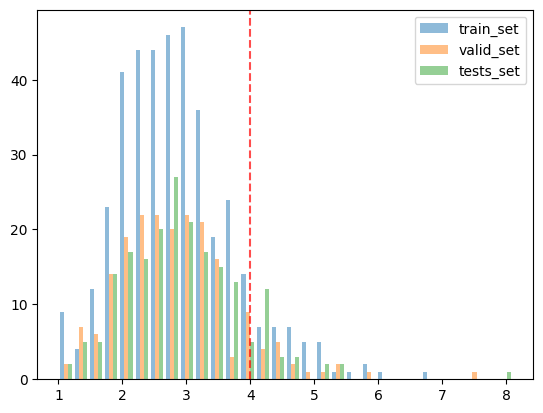

In [20]:
# --------------------------------------------------------------------------------
from torch.utils.data import TensorDataset, DataLoader

permute_indices = torch.LongTensor(rng.permutation(np.arange(pad_series_torch.shape[0])))
train_idx = permute_indices[:400]
valid_idx = permute_indices[400:600]
tests_idx = permute_indices[600:]

plt.hist([max_intensives[train_idx], max_intensives[valid_idx], max_intensives[tests_idx]], 
        bins=30, alpha=0.5, label=['train_set', 'valid_set','tests_set'])
plt.axvline(threshold, color='red', alpha=0.7, ls='--')
plt.legend()
plt.show()


In [21]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(label_true[tests_idx], label_torch[tests_idx]))   # true - obs
print(classification_report(label_torch[tests_idx], label_true[tests_idx]))   # true - obs

[[164  10]
 [  5  21]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       169
           1       0.81      0.68      0.74        31

    accuracy                           0.93       200
   macro avg       0.88      0.82      0.85       200
weighted avg       0.92      0.93      0.92       200



In [22]:
# Dataset
train_dataset = TensorDataset(pad_series_torch[train_idx,:,-2:], label_torch[train_idx])
valid_dataset = TensorDataset(pad_series_torch[valid_idx,:,-2:], label_torch[valid_idx])
tests_dataset = TensorDataset(pad_series_torch[tests_idx,:,-2:], label_torch[tests_idx])

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=True)
tests_loader = DataLoader(tests_dataset, batch_size=64, shuffle=True)


In [23]:
##########################################################################################
# class imbalance weights

# x = np.linspace(0, 1, num=100)
# xp = np.stack([x, 1-x])

# np.linspace(0, 1, num=11)
# T = [0.1, 0.5, 1, 1.5, 10]


# plt.plot(xp[0], xp[0], label='N')
# for t in T:
#     xp_exp = (np.exp(t * xp) / np.exp(t * xp).sum(0))
#     plt.plot(xp[0], xp_exp[0], label=f"T:{t}")
# plt.legend(loc='upper right', bbox_to_anchor=(1,1))
# plt.show()

In [24]:
##########################################################################################
# 【 Learnable SVM Kernel Model 】########################################################
##########################################################################################
import torch.nn as nn
import torch.optim as optim

class KernelModel(nn.Module):
    def __init__(self, kernel='gaussian'):
        super().__init__()
        self.kernel = kernel
        
        # self.params_Sigma =  nn.Parameter( torch.rand(()) )
        self.params_Sigma_vec = nn.Parameter( torch.rand(2) )
        self.params_boundary =  nn.Parameter( torch.rand(()) )
        self.param_threhold = nn.Parameter(torch.rand(()))
        
        self.Sigma = None
        self.Sigma_vec = None
        self.boundary = None
        self.threshold = None
        self.dist_layer = Kernel(kernel=kernel)
    
    def make_positive_params(self):
        # self.Sigma = nn.functional.softplus(self.params_Sigma) 
        self.Sigma_vec = nn.functional.softplus(self.params_Sigma_vec) 
        self.Sigma = self.Sigma_vec.diag()
        self.boundary = nn.functional.softplus(self.params_boundary) 
        self.threshold = nn.functional.softplus(self.param_threhold)
    
    def forward_intensive(self, X, Y=None):
        self.make_positive_params()
        
        # intensive = self.dist_layer(X, Y, Sigma=torch.tensor(1.5))
        if self.kernel == 'gaussian':
            intensive = self.dist_layer(X, Y, Sigma=self.Sigma)
        else:
            intensive_window = self.dist_layer(X, Y, boundary=self.boundary)
        return intensive
    
    def forward(self, X):
        intensive = self.forward_intensive(X)
        # intensive = self.dist_layer(X, boundary=self.boundary)
        max_intensive, _ = intensive.squeeze(-1).max(dim=-1, keepdim=True)
        
        output = max_intensive - self.threshold
        return output 

In [25]:

# torch.autograd.set_detect_anomaly(False)
model = KernelModel(kernel='gaussian').to(device)
# model(pad_series_torch[:,:,-2:].to(device))
print(f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

6


In [26]:
# load_state = torch.load("D:/DataScience/Model/ConvDeepSVM_params.pth")
# model.load_state_dict(load_state)
# model.make_positive_params()

In [27]:
# def squared_hingeloss(y_pred, y_true, margin=1):
#     return torch.clamp(margin - (y_true*2-1) * y_pred, min=0) ** 2

class BatchSquareHingeLoss():
    def __init__(self, num_classes=None, weights_method='equal'):
        """
         . weights_method : 'equal', 'ratio', 'exp'
        """
        self.weights = None
        self.weihts_method = weights_method
        if num_classes is not None:
            weights = num_classes / num_classes.sum()
            if self.weihts_method == 'exp':
                self.weights = torch.exp(weights) / torch.exp(weights).sum()
            self.weights = weights
    
    def loss_function(self, model, batch, optiimizer=None):
        batch_X, batch_y = batch
        batch_y_pn = batch_y*2 - 1
        y_pred = model.forward(batch_X)
        
        unique_class, num_classes_batch = batch_y.unique(return_counts=True)
        if len(unique_class) > 1:
            if self.weights is not None:
                weights = self.weights
            elif self.weihts_method == 'ratio':
                weights = num_classes_batch / num_classes_batch.sum()
            elif self.weihts_method == 'exp':
                weights = num_classes_batch / num_classes_batch.sum()
                weights = torch.exp(weights) / torch.exp(weights).sum()
            else:   # 'equal;
                weights = torch.ones(2)/2
        else:
            weights = torch.zeros(2)
            weights[unique_class] = 1
        
        hinge_loss = torch.tensor(0.0)
        if len(batch_y_pn[batch_y_pn < 0]) > 0:   # negative_loss
            hinge_loss += weights[0] * (torch.clamp(1 - batch_y_pn[batch_y_pn < 0] * y_pred[batch_y_pn < 0], min=0) ** 2).mean()
            
        if len(batch_y_pn[batch_y_pn > 0]) > 0:     # positive_loss
            hinge_loss += weights[1] * (torch.clamp(1 - batch_y_pn[batch_y_pn > 0] * y_pred[batch_y_pn > 0], min=0) ** 2).mean()
        
        return hinge_loss

In [28]:
squared_hinge_loss = BatchSquareHingeLoss(num_classes, weights_method='exp')  # num_classes   
# squared_hinge_loss = BatchSquareHingeLoss(weights_method='exp')  # num_classes

In [29]:
tm = TorchModeling(model)

In [30]:

tm.compile(optimizer=optim.AdamW(model.parameters(), lr=5e-4)
        #    ,early_stop_loss = EarlyStopping(min_iter=1500, patience=300)
           )


In [32]:
for _ in range(4):
    tm.train_model(train_loader, valid_loader, epochs=500,
                loss_function=squared_hinge_loss.loss_function)

    print(model.Sigma.detach(), model.threshold.detach())
    # print(model.Sigma.detach(), model.threshold.detach())
    # print(model.Precision.detach(), model.threshold.detach())
    # print(model.boundary.detach(), model.threshold.detach())

'[Epoch: 1498/1498] train_loss: 0.257,  valid_loss: 0.216'

tensor([[0.5883, 0.0000],
        [0.0000, 0.7639]]) tensor(2.9065)


'[Epoch: 1998/1998] train_loss: 0.169,  valid_loss: 0.22'

tensor([[1.1079, 0.0000],
        [0.0000, 1.4504]]) tensor(3.4484)


'[Epoch: 2498/2498] train_loss: 0.14,  valid_loss: 0.17'

tensor([[1.5106, 0.0000],
        [0.0000, 1.9526]]) tensor(3.8045)


'[Epoch: 2998/2998] train_loss: 0.141,  valid_loss: 0.163'

tensor([[1.6488, 0.0000],
        [0.0000, 2.2080]]) tensor(3.9599)


In [33]:
torch.save(model.state_dict(), "D:/DataScience/Model/DeepSVM_params_gaussian.pth")

In [34]:
# ----------------------------------------------------------------------
with torch.no_grad():
    pred = model(pad_series_torch[tests_idx,:,-2:]).detach().to('cpu').numpy()
    pred_label = ((np.sign(pred)+1)/2).ravel()

In [35]:

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(pred_label, label_torch[tests_idx]))   # pred - obs
print(classification_report(pred_label, label_torch[tests_idx]))   # pred - obs

[[163  13]
 [  6  18]]
              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94       176
         1.0       0.58      0.75      0.65        24

    accuracy                           0.91       200
   macro avg       0.77      0.84      0.80       200
weighted avg       0.92      0.91      0.91       200



In [36]:

print(confusion_matrix(label_true[tests_idx], label_torch[tests_idx]))   # true - obs
print(classification_report(label_torch[tests_idx], label_true[tests_idx]))   # true - obs

[[164  10]
 [  5  21]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       169
           1       0.81      0.68      0.74        31

    accuracy                           0.93       200
   macro avg       0.88      0.82      0.85       200
weighted avg       0.92      0.93      0.92       200



In [37]:

print(confusion_matrix(pred_label, label_true[tests_idx]))    # pred - true
print(classification_report(pred_label, label_true[tests_idx]))    # pred - true

[[173   3]
 [  1  23]]
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       176
         1.0       0.88      0.96      0.92        24

    accuracy                           0.98       200
   macro avg       0.94      0.97      0.95       200
weighted avg       0.98      0.98      0.98       200



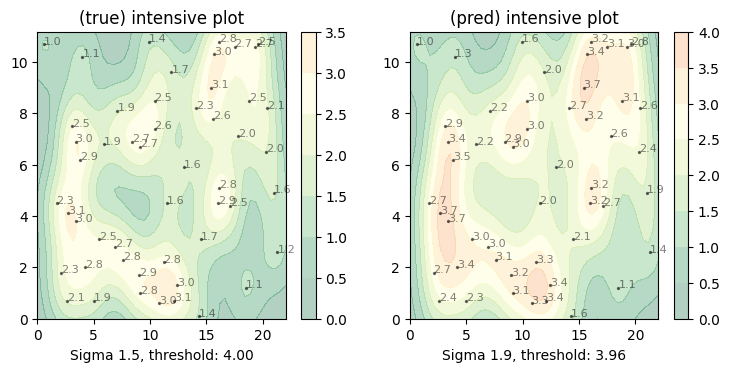

In [38]:
# ----------------------------------------------------------------------
# Visualize
xx, yy = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))
grid = np.c_[xx.ravel(), yy.ravel()]  # (40000, 2)

i = 376
mtl_sample = mtl_list[i]
x_scale, y_scale = map(lambda x: x.item(), mtl_sample.mean(0)[:2])
gird_scale = grid * np.array([x_scale, y_scale])
xx_scale = xx * x_scale
yy_scale = yy * y_scale

# visual dict
dist = Kernel(Sigma=torch.tensor(1.5), kernel='gaussian')

with torch.no_grad():
    Z_true = dist.forward(torch.FloatTensor(gird_scale), torch.FloatTensor(mtl_sample[:, -2:]) ).view(xx_scale.shape).detach().numpy()
    intensive_true = dist.forward(torch.FloatTensor(mtl_sample[:, -2:])).squeeze()

    Z_pred = model.forward_intensive(torch.FloatTensor(gird_scale), torch.FloatTensor(mtl_sample[:, -2:]) ).view(xx_scale.shape).detach().numpy()
    intensive_pred = model.forward_intensive(torch.FloatTensor(mtl_sample[:, -2:])).squeeze()

params = {'true':(dist.Sigma, 4), 'pred': (model.Sigma.detach().diagonal().mean().item(), round(model.threshold.detach().item(),2))}
Z = {'true':Z_true, 'pred': Z_pred}
intensive = {'true': intensive_true, 'pred': intensive_pred}

# visualize
plt.figure(figsize=[mtl_sample[0][0].item()/2.5 , mtl_sample[0][1].item()/3])
for ei, ((Z_name, Z_value), (i_name, i_value), (param_name, param_values)) in enumerate(zip(Z.items(), intensive.items(), params.items())):
    
    plt.subplot(1,2,ei+1)
    plt.title(f"({Z_name}) intensive plot")
    cont = plt.contourf(xx_scale, yy_scale, Z_value, cmap="RdYlGn_r", alpha=0.3, vmin=0.5, vmax=5)

    for (xp, yp), val in zip(mtl_sample[:,-2:], i_value):
        color='black'
        alpha=0.5
        if val >= float(param_values[1]):
            color='red'
            alpha= 1
        plt.scatter(xp.item(), yp.item(), color=color, s=2, alpha=alpha)
        plt.text(xp.item(), yp.item(), round(val.item(),1), color=color, alpha=alpha, fontsize=8)
    plt.xlabel(f"Sigma {float(param_values[0]):.1f}, threshold: {param_values[1]:.2f}")
    plt.colorbar(cont)
plt.show()

In [39]:
##########################################################################################
# 【 Convolutional Learnable SVM Kernel Model 】##########################################
##########################################################################################
import torch.nn as nn
import torch.optim as optim

class ConvKernelModel(nn.Module):
    def __init__(self, window_size=1000, stride=500, kernel='gaussian'):
        super().__init__()
        self.window_size = window_size
        self.stride = stride
        self.kernel = kernel
        
        # self.params_Sigma =  nn.Parameter( torch.rand(()) )
        self.params_Sigma_vec = nn.Parameter( torch.rand(2) )
        self.params_boundary =  nn.Parameter( torch.rand(()) )
        self.param_threhold = nn.Parameter(torch.rand(()))
        
        self.Sigma = None
        self.Sigma_vec = None
        self.boundary = None
        self.threshold = None
        self.dist_layer = Kernel(kernel=kernel)
    
    def sort_sequence(self, X, padding_value=-1.0, pad_all_features=True, descending=False):
            """
             . X: (..., Seq, Feature) > 2D
             . padding_value: 패딩 값 (예: -1)
             . pad_all_features: True  -> feature 중 하나라도 padding_value면 패딩으로 간주 (네 기존 로직)
                                False -> feature 전부가 padding_value일 때만 패딩으로 간주 (보통 패딩 벡터용)
            """
            seq_dim = -2      # (..., Seq, Feature)에서 Seq 축
            feature_dim = -1     # Feature 축

            # padding mask: (..., Seq)
            if pad_all_features:
                pad_mask = (X == padding_value).any(dim=feature_dim)
            else:
                pad_mask = (X == padding_value).all(dim=feature_dim)

            # 거리: (..., Seq)
            dist = torch.norm(X, dim=feature_dim)

            # 패딩을 뒤로 보내기 위한 score 조정
            #    - descending=False(가까운 순): 패딩은 +inf
            #    - descending=True (먼 순):   패딩은 -inf
            fill_value = float('-inf') if descending else float('inf')
            dist_masked = dist.masked_fill(pad_mask, fill_value)

            # 정렬 인덱스: (..., Seq)
            sort_idx = torch.argsort(dist_masked, dim=feature_dim, descending=descending)

            # gather를 위한 인덱스 확장: (..., Seq, Feature)
            sort_idx_expanded = sort_idx.unsqueeze(feature_dim).expand(*X.shape[:-1], X.size(feature_dim))

            # Seq 축으로 gather
            X_sorted = torch.gather(X, dim=seq_dim, index=sort_idx_expanded)

            # # 역순 인덱스 생성 (원래 순서 복원용)
            inverse_idx = torch.empty_like(sort_idx)
            inverse_idx.scatter_(feature_dim, sort_idx, torch.arange(sort_idx.size(feature_dim), device=sort_idx.device).expand(*sort_idx.shape))
            # inverse_idx_expanded = inverse_idx.unsqueeze(feature_dim).expand(*X.shape[:-1], X.size(feature_dim))
    
            return X_sorted, sort_idx, inverse_idx
    
    def make_positive_params(self):
        # self.Sigma = nn.functional.softplus(self.params_Sigma) 
        self.Sigma_vec = nn.functional.softplus(self.params_Sigma_vec) 
        self.Sigma = self.Sigma_vec.diag()
        self.boundary = nn.functional.softplus(self.params_boundary) 
        self.threshold = nn.functional.softplus(self.param_threhold)
    
    def forward_intensive(self, X, Y=None):
        self.make_positive_params()
        
        seq_len = X.shape[-2]
        X_sorted, sort_idx, inverse_idx = self.sort_sequence(X)
        self.sort_idx = sort_idx
        self.inverse_idx = inverse_idx
        
        n_window = 1 if seq_len < self.window_size else (seq_len - self.window_size + self.stride-1)//self.stride + 1
        
        # windowing forward
        intensives = []
        
        # 2안)
        # max_intensives = torch.full((*X_sorted.shape[:-2], seq_len, 1), 0.0, device=X.device, dtype=X.dtype)
        for i in range(n_window):
            # 1안)
            max_intensive_window = torch.full((*X_sorted.shape[:-2], seq_len, 1), 0.0, device=X.device, dtype=X.dtype)
            
            i_start, i_end = i*self.stride, min(i*self.stride+self.window_size, seq_len)
            if i_end - i_start <= 0:
                continue
            # print(i_start, i_end)
            X_window = X_sorted[...,i_start:i_end,:]
            if self.kernel == 'gaussian':
                intensive_window = self.dist_layer(X_window, Y, Sigma=self.Sigma)
            else:
                intensive_window = self.dist_layer(X_window, Y, boundary=self.boundary)

            # intensives.append(intensive_window)
            # 1안)
            max_intensive_window[..., i_start:i_end, :] = intensive_window
            intensives.append(max_intensive_window)
            
            # 2안)
            # cur_intensives = max_intensives[..., i_start:i_end, :].clone()
            # max_intensives[..., i_start:i_end, :] = torch.maximum(cur_intensives, intensive_window)
            
            # 3안)
            # idx = torch.arange(i_start, i_end, device=X.device).view(*([1]*(intensive_window.ndim-2)), i_end - i_start , 1).expand_as(intensive_window)
            # max_intensives = max_intensives.scatter_reduce(dim=-2, index=idx, src=intensive_window, reduce="amax", include_self=True)
            
        self.intensives_cat = torch.concat(intensives, dim=-1)
        max_intensive_sorted, _ = self.intensives_cat.max(dim=-1, keepdim=True)
        max_intensive = torch.gather(max_intensive_sorted, dim=-2, index=inverse_idx.unsqueeze(-1))
        return max_intensive
    
    def forward(self, X):       
        intensives_cat = self.forward_intensive(X)
        
        max_intensive, _ = intensives_cat.squeeze(-1).max(dim=-1, keepdim=True)
        output_window = max_intensive - self.threshold
        return output_window

In [40]:

model = ConvKernelModel(window_size=40, stride=20, kernel='gaussian').to(device)
# model = ConvKernelModel(window_size=40, stride=20, kernel='linear').to(device)
# model(pad_series_torch[:,:,-2:].to(device))
print(f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

6


In [41]:
# load_state = torch.load("D:/DataScience/Model/ConvDeepSVM_params_gaussian.pth")
# load_state = torch.load("D:/DataScience/Model/ConvDeepSVM_params_linear.pth")
# model.load_state_dict(load_state)
# model.make_positive_params()

In [42]:
class BatchSquareHingeLoss():
    def __init__(self, num_classes=None, weights_method='equal'):
        """
         . weights_method : 'equal', 'ratio', 'exp'
        """
        self.weights = None
        self.weihts_method = weights_method
        if num_classes is not None:
            weights = num_classes / num_classes.sum()
            if self.weihts_method == 'exp':
                self.weights = torch.exp(weights) / torch.exp(weights).sum()
            self.weights = weights
    
    def loss_function(self, model, batch, optiimizer=None):
        batch_X, batch_y = batch
        batch_y_pn = batch_y*2 - 1
        y_pred = model.forward(batch_X)
        
        unique_class, num_classes_batch = batch_y.unique(return_counts=True)
        if len(unique_class) > 1:
            if self.weights is not None:
                weights = self.weights
            elif self.weihts_method == 'ratio':
                weights = num_classes_batch / num_classes_batch.sum()
            elif self.weihts_method == 'exp':
                weights = num_classes_batch / num_classes_batch.sum()
                weights = torch.exp(weights) / torch.exp(weights).sum()
            else:   # 'equal;
                weights = torch.ones(2)/2
        else:
            weights = torch.zeros(2)
            weights[unique_class] = 1
        
        hinge_loss = torch.tensor(0.0)
        if len(batch_y_pn[batch_y_pn < 0]) > 0:   # negative_loss
            hinge_loss += weights[0] * (torch.clamp(1 - batch_y_pn[batch_y_pn < 0] * y_pred[batch_y_pn < 0], min=0) ** 2).mean()
            
        if len(batch_y_pn[batch_y_pn > 0]) > 0:     # positive_loss
            hinge_loss += weights[1] * (torch.clamp(1 - batch_y_pn[batch_y_pn > 0] * y_pred[batch_y_pn > 0], min=0) ** 2).mean()
        
        return hinge_loss

In [43]:
# torch.autograd.set_detect_anomaly(True)
squared_hinge_loss = BatchSquareHingeLoss(num_classes, weights_method='exp')  # num_classes   
# squared_hinge_loss = BatchSquareHingeLoss(weights_method='exp')  # num_classes

In [44]:

tm = TorchModeling(model)

In [45]:

tm.compile(optimizer=optim.AdamW(model.parameters(), lr=5e-4)
        #    ,early_stop_loss = EarlyStopping(min_iter=1200, patience=300)
           )

In [46]:
for _ in range(4):
    tm.train_model(train_loader, valid_loader, epochs=500,
                loss_function=squared_hinge_loss.loss_function)

    print(model.Sigma.detach(), model.threshold.detach())
    # print(model.Sigma.detach(), model.threshold.detach())
    # print(model.Precision.detach(), model.threshold.detach())
    # print(model.boundary.detach(), model.threshold.detach())

'[Epoch: 500/500] train_loss: 0.633,  valid_loss: 0.64'

tensor([[0.3995, 0.0000],
        [0.0000, 0.3707]]) tensor(1.9648)


'[Epoch: 1000/1000] train_loss: 0.277,  valid_loss: 0.275'

tensor([[0.3347, 0.0000],
        [0.0000, 0.3321]]) tensor(2.5208)


'[Epoch: 1500/1500] train_loss: 0.215,  valid_loss: 0.333'

tensor([[0.6443, 0.0000],
        [0.0000, 0.7807]]) tensor(2.9461)


'[Epoch: 2000/2000] train_loss: 0.177,  valid_loss: 0.196'

tensor([[1.1756, 0.0000],
        [0.0000, 1.4623]]) tensor(3.4792)


In [47]:
torch.save(model.state_dict(), "D:/DataScience/Model/ConvDeepSVM_params_gaussian.pth")

In [48]:
# ----------------------------------------------------------------------
with torch.no_grad():
    pred = model(pad_series_torch[tests_idx,:,-2:]).detach().to('cpu').numpy()
    pred_label = ((np.sign(pred)+1)/2).ravel()

In [49]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(pred_label, label_torch[tests_idx]))   # pred - obs
print(classification_report(pred_label, label_torch[tests_idx]))   # pred - obs

[[164  15]
 [  5  16]]
              precision    recall  f1-score   support

         0.0       0.97      0.92      0.94       179
         1.0       0.52      0.76      0.62        21

    accuracy                           0.90       200
   macro avg       0.74      0.84      0.78       200
weighted avg       0.92      0.90      0.91       200



In [50]:
print(confusion_matrix(label_true[tests_idx], label_torch[tests_idx]))   # true - obs
print(classification_report(label_torch[tests_idx], label_true[tests_idx]))   # true - obs

[[164  10]
 [  5  21]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       169
           1       0.81      0.68      0.74        31

    accuracy                           0.93       200
   macro avg       0.88      0.82      0.85       200
weighted avg       0.92      0.93      0.92       200



In [51]:
print(confusion_matrix(pred_label, label_true[tests_idx]))    # pred - true
print(classification_report(pred_label, label_true[tests_idx]))    # pred - true

[[172   7]
 [  2  19]]
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97       179
         1.0       0.73      0.90      0.81        21

    accuracy                           0.95       200
   macro avg       0.86      0.93      0.89       200
weighted avg       0.96      0.95      0.96       200



In [52]:

# ----------------------------------------------------------------------
# torch.where(label_torch==1)      # label_obs
# np.where(pred_label==1)          # label_pred
# np.where(label_true==1)           # label_true


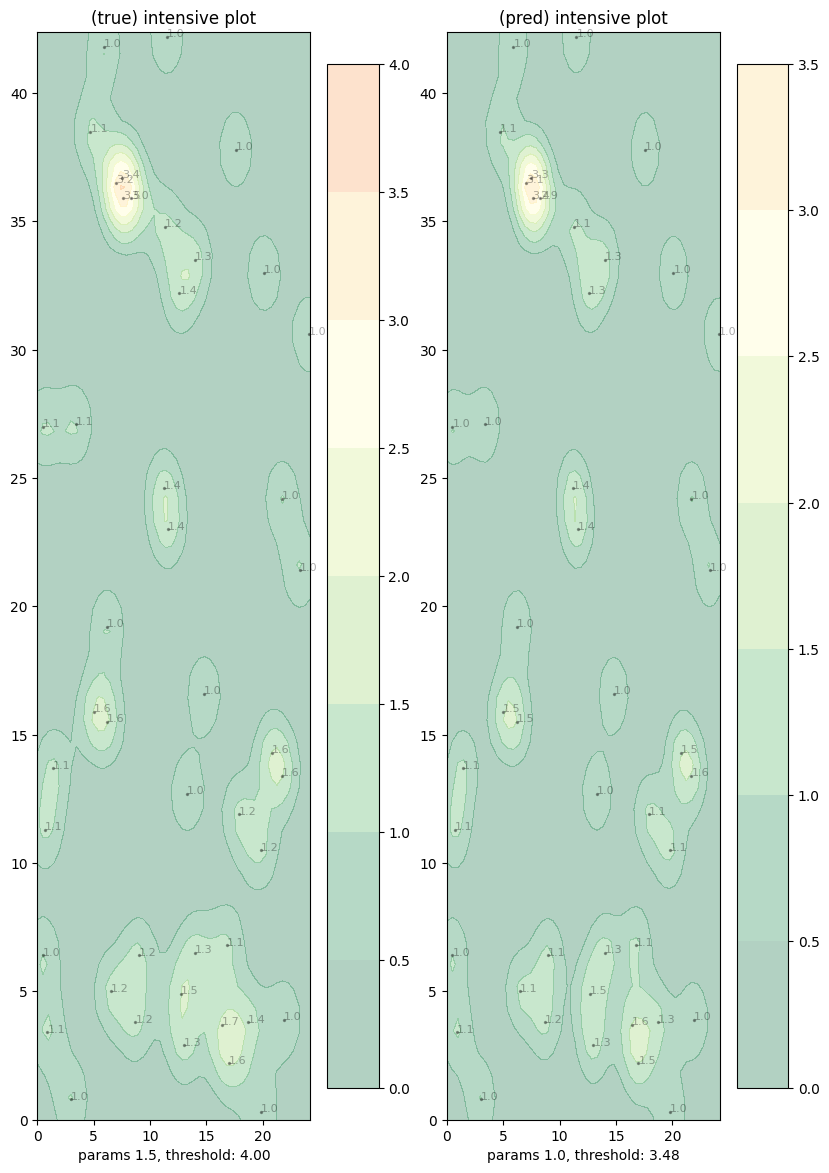

In [53]:


# ----------------------------------------------------------------------
# Visualize
xx, yy = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))
grid = np.c_[xx.ravel(), yy.ravel()]  # (40000, 2)

i = 67
mtl_sample = mtl_list[i]
x_scale, y_scale = map(lambda x: x.item(), mtl_sample.mean(0)[:2])
gird_scale = grid * np.array([x_scale, y_scale])
xx_scale = xx * x_scale
yy_scale = yy * y_scale

# visual dict
dist = Kernel(Sigma=torch.tensor(1.5), kernel='gaussian')

with torch.no_grad():
    Z_true = dist.forward(torch.FloatTensor(gird_scale), torch.FloatTensor(mtl_sample[:, -2:]) ).view(xx_scale.shape).detach().numpy()
    intensive_true = dist.forward(torch.FloatTensor(mtl_sample[:, -2:])).squeeze()

    Z_pred = model.forward_intensive(torch.FloatTensor(gird_scale), torch.FloatTensor(mtl_sample[:, -2:]) ).view(xx_scale.shape).detach().numpy()
    intensive_pred = model.forward_intensive(torch.FloatTensor(mtl_sample[:, -2:])).squeeze()


# params = {'true':(dist.Sigma, 4), 'pred': (model.Sigma.detach().diagonal().mean().item(), round(model.threshold.detach().item(),2))}
params = {'true':(dist.Sigma, 4), 'pred': (model.boundary.detach().item(), round(model.threshold.detach().item(),2))}
Z = {'true':Z_true, 'pred': Z_pred}
intensive = {'true': intensive_true, 'pred': intensive_pred}

# visualize
plt.figure(figsize=[mtl_sample[0][0].item()/2.5 , mtl_sample[0][1].item()/3])
for ei, ((Z_name, Z_value), (i_name, i_value), (param_name, param_values)) in enumerate(zip(Z.items(), intensive.items(), params.items())):
    
    plt.subplot(1,2,ei+1)
    plt.title(f"({Z_name}) intensive plot")
    # cont = plt.contourf(xx_scale, yy_scale, Z_value, cmap="RdYlGn_r", alpha=0.3, vmin=0.5, vmax=5, levels=np.sqrt(np.linspace(0, 25, 10)) )
    cont = plt.contourf(xx_scale, yy_scale, Z_value, cmap="RdYlGn_r", alpha=0.3, vmin=0.5, vmax=5)

    for (xp, yp), val in zip(mtl_sample[:,-2:], i_value):
        color='black'
        alpha=0.33
        if val >= float(param_values[1]):
            color='red'
            alpha= 1
        plt.scatter(xp.item(), yp.item(), color=color, s=2, alpha=alpha)
        plt.text(xp.item(), yp.item(), round(val.item(),1), color=color, alpha=alpha, fontsize=8)
    plt.xlabel(f"params {float(param_values[0]):.1f}, threshold: {param_values[1]:.2f}")
    plt.colorbar(cont)
plt.show()

##########################################################################################

